# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## Carga de los datos

In [17]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import pandas as pd
import keras.datasets.cifar10 as cifar10

from tensorflow import keras
from keras.utils import to_categorical

In [18]:
# Primero, definimos los datos de entrenamiento, validación y prueba
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

In [19]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

In [20]:
# Esta variable contiene un mapeo de número de clase a elemento (animal o vehículo).
# La incluimos para ayudarte con la identificación de clases. De ti depende
# si quieres utilizar esta variable o no
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

In [21]:
# Función auxiliar para convertir las etiquetas a codificación one-hot
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# Convertimos las etiquetas de entrenamiento, validación y prueba
num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# Verificamos las conversiones
print(y_train_one_hot.shape)
print(y_valid_one_hot.shape)
print(y_test_one_hot.shape)

(40000, 10)
(10000, 10)
(10000, 10)


## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

---

# Desarrollo de la actividad

En esta parte se presenta la resolución del ejercicio de clasificación de imágenes CIFAR-10 mediante redes neuronales convolucionales. Se mantiene la carga de datos propuesta en el enunciado y se utilizan las particiones de entrenamiento, validación y test ya definidas. El análisis compara un modelo fully connected con varias arquitecturas CNN, incorporando regularización, batch normalization, data augmentation y métricas por clase.

## 1. Configuración reproducible y utilidades iniciales

Se fijan semillas y se cargan las librerías necesarias para que las comparaciones entre modelos se realicen bajo las mismas condiciones. Los primeros modelos sirven como referencia y el análisis posterior permite valorar el efecto de la profundidad, la regularización, el batch normalization y el data augmentation.

In [22]:
import random
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
BATCH_SIZE = 128

# Configuración equilibrada: permite obtener resultados comparables sin tiempos de ejecución excesivos.
EPOCHS_BASELINE = 8
EPOCHS_SIMPLE_CNN = 10
EPOCHS_REGULARIZED_CNN = 14
EPOCHS_FINAL = 25

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

class_names = [MAP_ELEMENTS[i] for i in range(num_classes)]
y_train_flat = y_train.reshape(-1)
y_valid_flat = y_valid.reshape(-1)
y_test_flat = y_test.reshape(-1)

print("TensorFlow:", tf.__version__)
print("Dispositivos GPU detectados:", tf.config.list_physical_devices('GPU'))
print("Clases:", class_names)

TensorFlow: 2.20.0
Dispositivos GPU detectados: []
Clases: ['avion', 'coche', 'ave', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camion']


## 2. Análisis exploratorio de CIFAR-10

Antes de entrenar los modelos se revisa el tamaño de los conjuntos, el equilibrio de clases y algunos ejemplos visuales. CIFAR-10 es más complejo que otros datasets sencillos de imágenes porque trabaja con imágenes RGB y los objetos pueden aparecer con variaciones de fondo, posición, escala y orientación.

In [23]:
def dataset_summary():
    resumen = pd.DataFrame({
        "conjunto": ["train", "valid", "test"],
        "imagenes": [len(x_train), len(x_valid), len(x_test)],
        "alto": [x_train.shape[1], x_valid.shape[1], x_test.shape[1]],
        "ancho": [x_train.shape[2], x_valid.shape[2], x_test.shape[2]],
        "canales": [x_train.shape[3], x_valid.shape[3], x_test.shape[3]],
        "min_pixel": [x_train.min(), x_valid.min(), x_test.min()],
        "max_pixel": [x_train.max(), x_valid.max(), x_test.max()],
    })
    return resumen

dataset_summary()

,conjunto,imagenes,alto,ancho,canales,min_pixel,max_pixel
0,train,40000,32,32,3,0.0,1.0
1,valid,10000,32,32,3,0.0,1.0
2,test,10000,32,32,3,0.0,1.0


conjunto,test,train,valid
clase,,,
avion,1000,3986,1014
coche,1000,3986,1014
ave,1000,4048,952
gato,1000,3984,1016
ciervo,1000,4003,997
perro,1000,3975,1025
rana,1000,4020,980
caballo,1000,4023,977
barco,1000,3997,1003


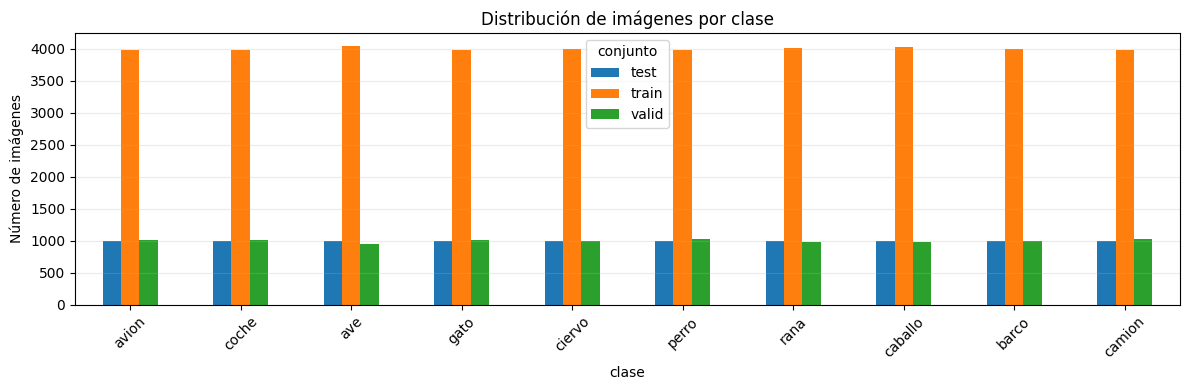

In [24]:
def class_distribution(labels, name):
    counts = np.bincount(labels.reshape(-1), minlength=num_classes)
    return pd.DataFrame({
        "conjunto": name,
        "clase_id": np.arange(num_classes),
        "clase": class_names,
        "imagenes": counts,
        "porcentaje": counts / counts.sum() * 100,
    })

dist_df = pd.concat([
    class_distribution(y_train, "train"),
    class_distribution(y_valid, "valid"),
    class_distribution(y_test, "test"),
], ignore_index=True)

pivot_dist = dist_df.pivot(index="clase", columns="conjunto", values="imagenes").loc[class_names]
display(pivot_dist)

ax = pivot_dist.plot(kind="bar", figsize=(12, 4), rot=45)
ax.set_title("Distribución de imágenes por clase")
ax.set_ylabel("Número de imágenes")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

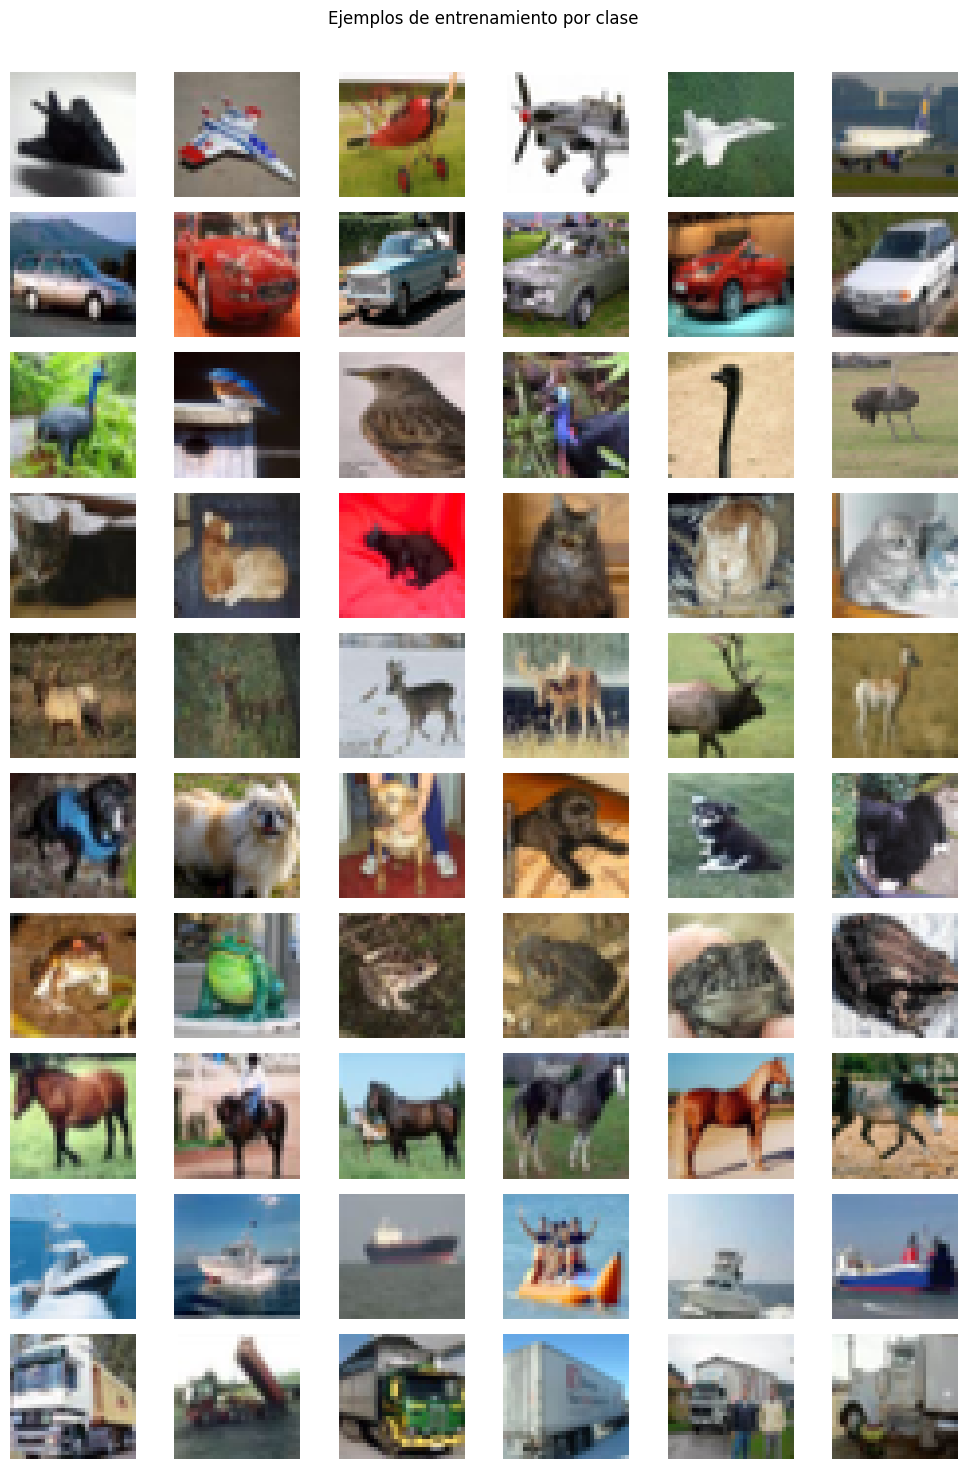

In [25]:
def plot_examples_per_class(images, labels, examples_per_class=6):
    labels = labels.reshape(-1)
    fig, axes = plt.subplots(num_classes, examples_per_class, figsize=(examples_per_class * 1.7, num_classes * 1.45))
    for class_id, class_name in enumerate(class_names):
        idx = np.where(labels == class_id)[0][:examples_per_class]
        for col, image_idx in enumerate(idx):
            ax = axes[class_id, col]
            ax.imshow(images[image_idx])
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_name, rotation=0, labelpad=32, va="center")
    fig.suptitle("Ejemplos de entrenamiento por clase", y=1.01)
    plt.tight_layout()
    plt.show()

plot_examples_per_class(x_train, y_train, examples_per_class=6)

**Conclusión del análisis de datos.** Las particiones mantienen una distribución equilibrada de clases, por lo que la accuracy global es una métrica válida para comparar modelos. Aun así, también se analizan precision, recall y F1-score por clase, ya que algunas categorías pueden confundirse entre sí. Esto es especialmente relevante en clases de animales como `gato`, `perro`, `ciervo` y `caballo`, que comparten texturas y formas, y en vehículos como `coche` y `camion`, que pueden presentar siluetas similares en imágenes de baja resolución.

## 3. Funciones auxiliares de entrenamiento y evaluación

Se definen funciones comunes para compilar, entrenar, evaluar y representar los modelos. De esta forma todos los experimentos se comparan con el mismo criterio y el código queda más claro y ordenado.

In [26]:
results = []
histories = {}
models = {}

def reset_random_state():
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)


def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def make_callbacks(model_name, patience=7):
    checkpoint_path = f"best_{model_name}.keras"
    return [
        ModelCheckpoint(
            checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=0,
        ),
        EarlyStopping(
            monitor="val_accuracy",
            patience=patience,
            mode="max",
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(2, patience // 2),
            min_lr=1e-6,
            verbose=1,
        ),
    ]


def train_and_evaluate(model_name, model, epochs, patience=6, verbose=1):
    reset_random_state()
    callbacks = make_callbacks(model_name, patience=patience)
    history = model.fit(
        x_train,
        y_train_one_hot,
        validation_data=(x_valid, y_valid_one_hot),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=verbose,
    )

    valid_loss, valid_accuracy = model.evaluate(x_valid, y_valid_one_hot, verbose=0)
    test_loss, test_accuracy = model.evaluate(x_test, y_test_one_hot, verbose=0)

    histories[model_name] = history
    models[model_name] = model
    results.append({
        "modelo": model_name,
        "epochs_ejecutadas": len(history.history["loss"]),
        "valid_loss": valid_loss,
        "valid_accuracy": valid_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "parametros": model.count_params(),
    })

    print(f"{model_name} -> val_accuracy={valid_accuracy:.4f} | test_accuracy={test_accuracy:.4f}")
    return history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="valid")
    axes[0].set_title(f"{title}: accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="valid")
    axes[1].set_title(f"{title}: loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


def results_table():
    df = pd.DataFrame(results).sort_values("valid_accuracy", ascending=False)
    metric_cols = ["valid_loss", "valid_accuracy", "test_loss", "test_accuracy"]
    formatted = df.copy()
    formatted[metric_cols] = formatted[metric_cols].round(4)
    return formatted.reset_index(drop=True)

## 4. Modelo baseline Fully Connected

El primer modelo aplana la imagen y utiliza capas densas. Este enfoque sirve como referencia inicial, pero no aprovecha la estructura espacial de las imágenes. Por este motivo se espera que tenga peor rendimiento que los modelos convolucionales.

In [27]:
def build_fully_connected_model():
    model = tf.keras.Sequential([
        layers.Input(shape=x_train.shape[1:]),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.40),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.35),
        layers.Dense(num_classes, activation="softmax"),
    ], name="fully_connected_baseline")
    return compile_model(model, learning_rate=1e-3)

fc_model = build_fully_connected_model()
fc_model.summary()

Model: "fully_connected_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,410 (3.14 MB)

 Trainable params: 821,642 (3.13 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.2916 - loss: 2.0939 - val_accuracy: 0.3271 - val_loss: 1.8789 - learning_rate: 0.0010
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.3566 - loss: 1.8090 - val_accuracy: 0.4040 - val_loss: 1.7087 - learning_rate: 0.0010
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3768 - loss: 1.7420 - val_accuracy: 0.3673 - val_loss: 1.7528 - learning_rate: 0.0010
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.3914 - loss: 1.7066 - val_accuracy: 0.4043 - val_loss: 1.6848 - learning_rate: 0.0010
Epoch 5/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.3899 - loss: 1.7035 - val_accuracy: 0.4210 - val_loss: 1.6381 - learning_rate: 0.0010
Epoch 6/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4029 - loss: 1.6744 - val_accuracy: 0.3984 - val_loss: 1.6677 - learning_rate: 0.0010
Epoch 7/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4039 - loss: 1.6703

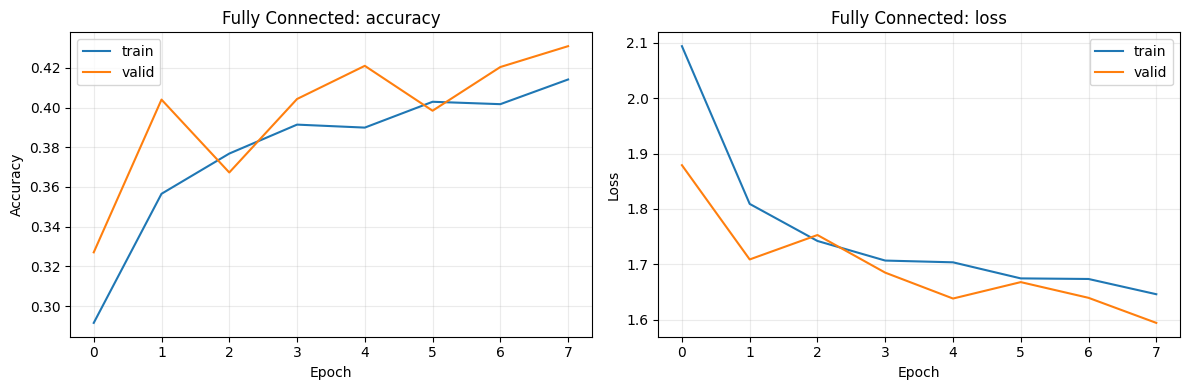

In [28]:
history_fc = train_and_evaluate(
    "fully_connected",
    fc_model,
    epochs=EPOCHS_BASELINE,
    patience=3,
    verbose=1,
)
plot_history(history_fc, "Fully Connected")

## 5. Primera CNN simple

La primera red convolucional utiliza dos bloques de convolución y pooling. Esta arquitectura ya conserva información espacial local y permite aprender filtros útiles para detectar bordes, texturas y formas básicas.

In [29]:
def build_simple_cnn():
    model = tf.keras.Sequential([
        layers.Input(shape=x_train.shape[1:]),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation="softmax"),
    ], name="simple_cnn")
    return compile_model(model, learning_rate=1e-3)

simple_cnn = build_simple_cnn()
simple_cnn.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 224ms/step - accuracy: 0.4017 - loss: 1.6401 - val_accuracy: 0.5361 - val_loss: 1.3481 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 238ms/step - accuracy: 0.5456 - loss: 1.2718 - val_accuracy: 0.6033 - val_loss: 1.1426 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - accuracy: 0.6004 - loss: 1.1293 - val_accuracy: 0.6325 - val_loss: 1.0568 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 239ms/step - accuracy: 0.6313 - loss: 1.0470 - val_accuracy: 0.6514 - val_loss: 0.9935 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 219ms/step - accuracy: 0.6565 - loss: 0.9716 - val_accuracy: 0.6662 - val_loss: 0.9563 - learning_rate: 0.0010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 219ms/step - accuracy: 0.6764 - loss: 0.9197 - val_accuracy: 0.6681 - val_loss: 0.9497 - learning_rate: 0.0010
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 219ms/step - accuracy: 0.6

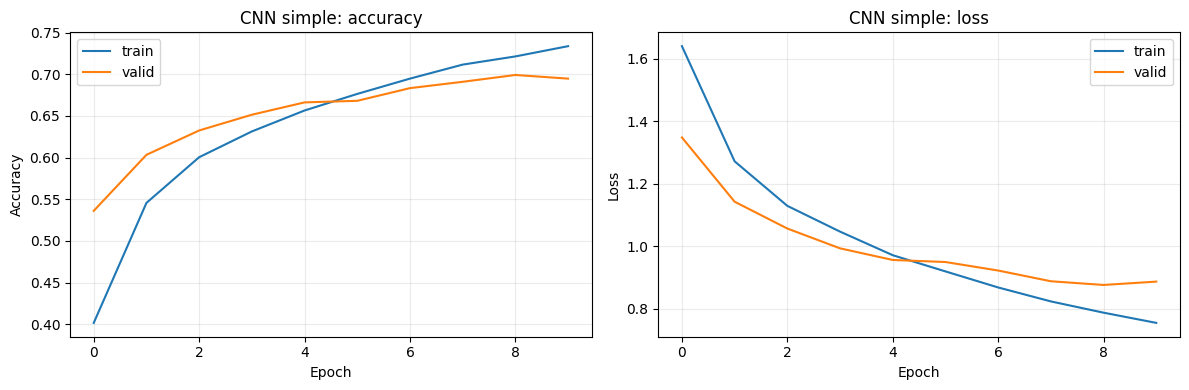

In [30]:
history_simple_cnn = train_and_evaluate(
    "simple_cnn",
    simple_cnn,
    epochs=EPOCHS_SIMPLE_CNN,
    patience=4,
    verbose=1,
)
plot_history(history_simple_cnn, "CNN simple")

## 6. CNN con Batch Normalization y regularización

El siguiente modelo aumenta la profundidad y añade técnicas de regularización. `BatchNormalization` estabiliza el entrenamiento, `Dropout` reduce el sobreajuste y la regularización L2 penaliza pesos demasiado grandes. El objetivo es comprobar si una CNN más controlada generaliza mejor que la CNN simple.

In [31]:
def conv_block(filters, weight_decay=1e-4, dropout=0.25):
    return tf.keras.Sequential([
        layers.Conv2D(filters, (3, 3), padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(filters, (3, 3), padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout),
    ])


def build_regularized_cnn():
    inputs = layers.Input(shape=x_train.shape[1:])
    x = conv_block(32, dropout=0.20)(inputs)
    x = conv_block(64, dropout=0.30)(x)
    x = conv_block(128, dropout=0.40)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.50)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs, name="regularized_cnn")
    return compile_model(model, learning_rate=1e-3)

regularized_cnn = build_regularized_cnn()
regularized_cnn.summary()

Model: "regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 16, 16, 32)     │        10,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 8, 8, 64)       │        55,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 4, 4, 128)      │       222,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,970 (1.24 MB)

 Trainable params: 323,562 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 396s 1s/step - accuracy: 0.3848 - loss: 1.8085 - val_accuracy: 0.1163 - val_loss: 3.5221 - learning_rate: 0.0010
Epoch 2/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - accuracy: 0.5627 - loss: 1.2621 - val_accuracy: 0.5168 - val_loss: 1.4447 - learning_rate: 0.0010
Epoch 3/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 458s 1s/step - accuracy: 0.6327 - loss: 1.0875 - val_accuracy: 0.5765 - val_loss: 1.2740 - learning_rate: 0.0010
Epoch 4/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 439s 1s/step - accuracy: 0.6694 - loss: 0.9905 - val_accuracy: 0.6814 - val_loss: 0.9405 - learning_rate: 0.0010
Epoch 5/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.6992 - loss: 0.9110 - val_accuracy: 0.6093 - val_loss: 1.2247 - learning_rate: 0.0010
Epoch 6/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7168 - loss: 0.8684
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.7220 - loss: 0.851

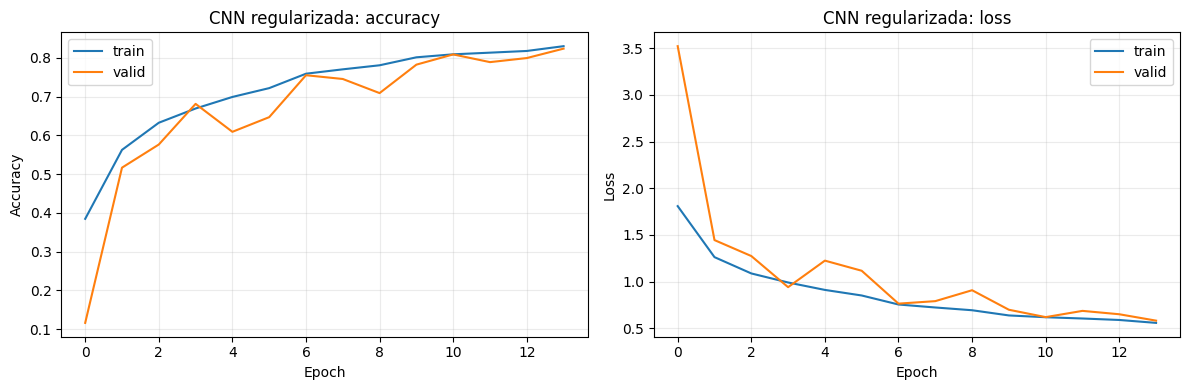

In [32]:
history_regularized_cnn = train_and_evaluate(
    "regularized_cnn",
    regularized_cnn,
    epochs=EPOCHS_REGULARIZED_CNN,
    patience=5,
    verbose=1,
)
plot_history(history_regularized_cnn, "CNN regularizada")

## 7. CNN con data augmentation

También se entrena una CNN con data augmentation para estudiar si el aumento artificial de datos mejora la generalización. Durante el entrenamiento se aplican transformaciones moderadas que conservan la clase de la imagen, como volteos horizontales, pequeñas traslaciones, rotaciones y zoom. Esta técnica resulta adecuada en CIFAR-10 porque aumenta la variedad de ejemplos sin modificar el conjunto original.

In [33]:
def build_final_augmented_cnn():
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomTranslation(0.08, 0.08, seed=SEED),
        layers.RandomRotation(0.06, seed=SEED),
        layers.RandomZoom(0.08, seed=SEED),
    ], name="data_augmentation")

    inputs = layers.Input(shape=x_train.shape[1:])
    x = data_augmentation(inputs)
    x = conv_block(32, dropout=0.20)(x)
    x = conv_block(64, dropout=0.30)(x)
    x = conv_block(128, dropout=0.40)(x)
    x = layers.Conv2D(128, (3, 3), padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(192, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.45)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs, name="final_augmented_cnn")
    return compile_model(model, learning_rate=1e-3)

final_cnn = build_final_augmented_cnn()
final_cnn.summary()

Model: "final_augmented_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 16, 16, 32)     │        10,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 8, 8, 64)       │        55,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 4, 4, 128)      │       222,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 192)            │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 463,786 (1.77 MB)

 Trainable params: 462,250 (1.76 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 436s 1s/step - accuracy: 0.3559 - loss: 1.8847 - val_accuracy: 0.1500 - val_loss: 3.8272 - learning_rate: 0.0010
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 455s 1s/step - accuracy: 0.4923 - loss: 1.4717 - val_accuracy: 0.4002 - val_loss: 1.8828 - learning_rate: 0.0010
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.5641 - loss: 1.2958 - val_accuracy: 0.5382 - val_loss: 1.4441 - learning_rate: 0.0010
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 443s 1s/step - accuracy: 0.6006 - loss: 1.1961 - val_accuracy: 0.5127 - val_loss: 1.6378 - learning_rate: 0.0010
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.6342 - loss: 1.1191 - val_accuracy: 0.5444 - val_loss: 1.4762 - learning_rate: 0.0010
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6499 - loss: 1.0742
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.6576 - loss: 1.057

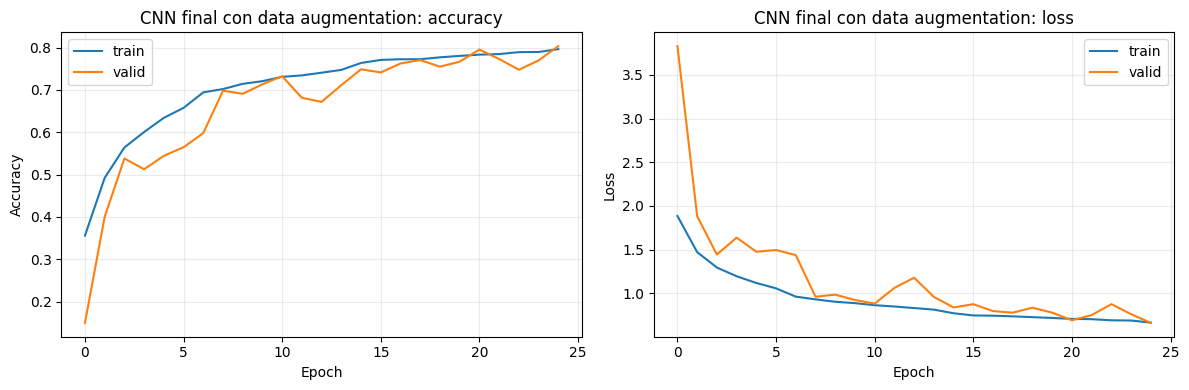

In [34]:
# Se muestra el entrenamiento completo del modelo final, tal como se solicita en el enunciado.
history_final_cnn = train_and_evaluate(
    "final_augmented_cnn",
    final_cnn,
    epochs=EPOCHS_FINAL,
    patience=7,
    verbose=1,
)
plot_history(history_final_cnn, "CNN final con data augmentation")

## 8. Comparación global de modelos

La tabla resume los resultados de las arquitecturas probadas. El modelo se selecciona utilizando la accuracy de validación, ya que el conjunto de test debe reservarse para la evaluación final. Después se informa también de la accuracy en test para comprobar la capacidad de generalización.

En la comparación se tienen en cuenta varios hiperparámetros y decisiones de diseño: número de épocas, profundidad de la red, número de filtros convolucionales, dropout, regularización L2, batch normalization y uso de data augmentation. Esto permite valorar no solo qué modelo obtiene mayor accuracy, sino también qué técnicas aportan mejoras respecto al modelo fully connected inicial.

,modelo,epochs_ejecutadas,valid_loss,valid_accuracy,test_loss,test_accuracy,parametros
0,regularized_cnn,14,0.5819,0.8239,0.5952,0.8172,324970
1,final_augmented_cnn,25,0.6626,0.8033,0.6795,0.7974,463786
2,simple_cnn,10,0.8764,0.6991,0.8824,0.6951,545098
3,fully_connected,8,1.5941,0.4309,1.5659,0.4360,822410


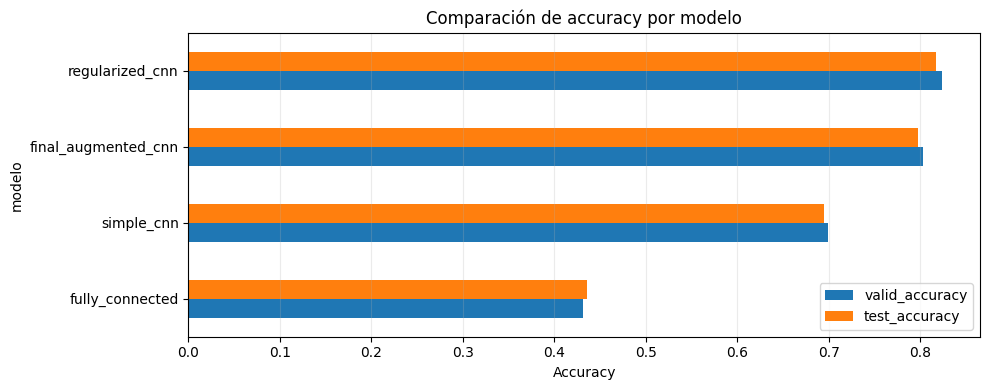

Mejor modelo según validación: regularized_cnn


In [35]:
comparison_df = results_table()
display(comparison_df)

ax = comparison_df.sort_values("valid_accuracy").plot(
    x="modelo",
    y=["valid_accuracy", "test_accuracy"],
    kind="barh",
    figsize=(10, 4),
)
ax.set_title("Comparación de accuracy por modelo")
ax.set_xlabel("Accuracy")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

best_model_name = comparison_df.iloc[0]["modelo"]
best_model = models[best_model_name]
print("Mejor modelo según validación:", best_model_name)

## 9. Evaluación detallada del mejor modelo

El mejor modelo se analiza con métricas por clase para comprobar si el resultado global es equilibrado. En este punto se calculan precision, recall y F1-score, además de la matriz de confusión.

In [36]:
def predict_classes(model, images):
    probabilities = model.predict(images, batch_size=BATCH_SIZE, verbose=0)
    return np.argmax(probabilities, axis=1), probabilities

best_test_loss, best_test_accuracy = best_model.evaluate(x_test, y_test_one_hot, verbose=0)
print(f"Evaluación final en test -> loss={best_test_loss:.4f} | accuracy={best_test_accuracy:.4f}")

y_pred, y_pred_proba = predict_classes(best_model, x_test)
report_dict = classification_report(
    y_test_flat,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_df[["precision", "recall", "f1-score"]] = report_df[["precision", "recall", "f1-score"]].round(4)
display(report_df)

Evaluación final en test -> loss=0.5952 | accuracy=0.8172


,precision,recall,f1-score,support
avion,0.8080,0.8670,0.8365,1000.0000
coche,0.9268,0.9120,0.9194,1000.0000
ave,0.7077,0.7650,0.7352,1000.0000
gato,0.7313,0.5580,0.6330,1000.0000
ciervo,0.7881,0.8180,0.8027,1000.0000
perro,0.7966,0.6540,0.7183,1000.0000
rana,0.7547,0.9230,0.8304,1000.0000
caballo,0.8641,0.8520,0.8580,1000.0000
barco,0.9032,0.9140,0.9085,1000.0000
camion,0.8921,0.9090,0.9004,1000.0000


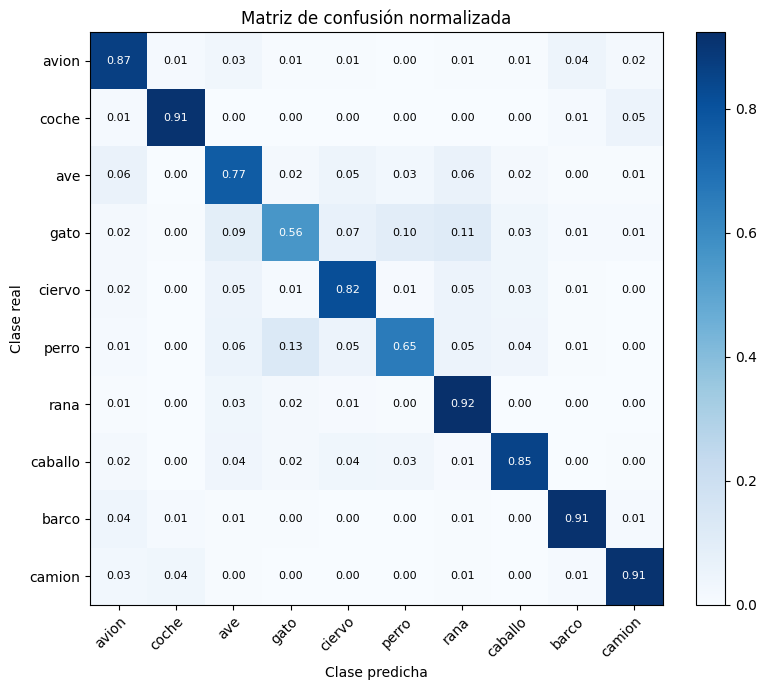

In [37]:
def plot_confusion_matrix(y_true, y_pred, normalize=True):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm_to_plot = cm / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
        title = "Matriz de confusión normalizada"
    else:
        cm_to_plot = cm
        fmt = "d"
        title = "Matriz de confusión"

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm_to_plot, cmap="Blues")
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(
        xticks=np.arange(num_classes),
        yticks=np.arange(num_classes),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="Clase real",
        xlabel="Clase predicha",
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    threshold = cm_to_plot.max() / 2
    for i in range(num_classes):
        for j in range(num_classes):
            color = "white" if cm_to_plot[i, j] > threshold else "black"
            ax.text(j, i, format(cm_to_plot[i, j], fmt), ha="center", va="center", color=color, fontsize=8)

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test_flat, y_pred, normalize=True)

In [38]:
def class_metric_summary(report_df):
    class_rows = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
    class_rows["support"] = class_rows["support"].astype(int)
    return class_rows.sort_values("f1-score", ascending=False)

class_summary = class_metric_summary(report_df)
display(class_summary)

print("Clases con mejor F1-score:")
display(class_summary.head(3))
print("Clases con peor F1-score:")
display(class_summary.tail(3))

,precision,recall,f1-score,support
coche,0.9268,0.912,0.9194,1000
barco,0.9032,0.914,0.9085,1000
camion,0.8921,0.909,0.9004,1000
caballo,0.8641,0.852,0.8580,1000
avion,0.8080,0.867,0.8365,1000
rana,0.7547,0.923,0.8304,1000
ciervo,0.7881,0.818,0.8027,1000
ave,0.7077,0.765,0.7352,1000
perro,0.7966,0.654,0.7183,1000
gato,0.7313,0.558,0.6330,1000


Clases con mejor F1-score:


,precision,recall,f1-score,support
coche,0.9268,0.912,0.9194,1000
barco,0.9032,0.914,0.9085,1000
camion,0.8921,0.909,0.9004,1000


Clases con peor F1-score:


,precision,recall,f1-score,support
ave,0.7077,0.765,0.7352,1000
perro,0.7966,0.654,0.7183,1000
gato,0.7313,0.558,0.6330,1000


## 10. Análisis visual de errores

Se muestran ejemplos mal clasificados para interpretar el comportamiento del modelo más allá de las métricas numéricas. En CIFAR-10 los errores suelen aparecer cuando el objeto es pequeño, el fondo tiene mucho peso visual o dos clases comparten formas y texturas parecidas.

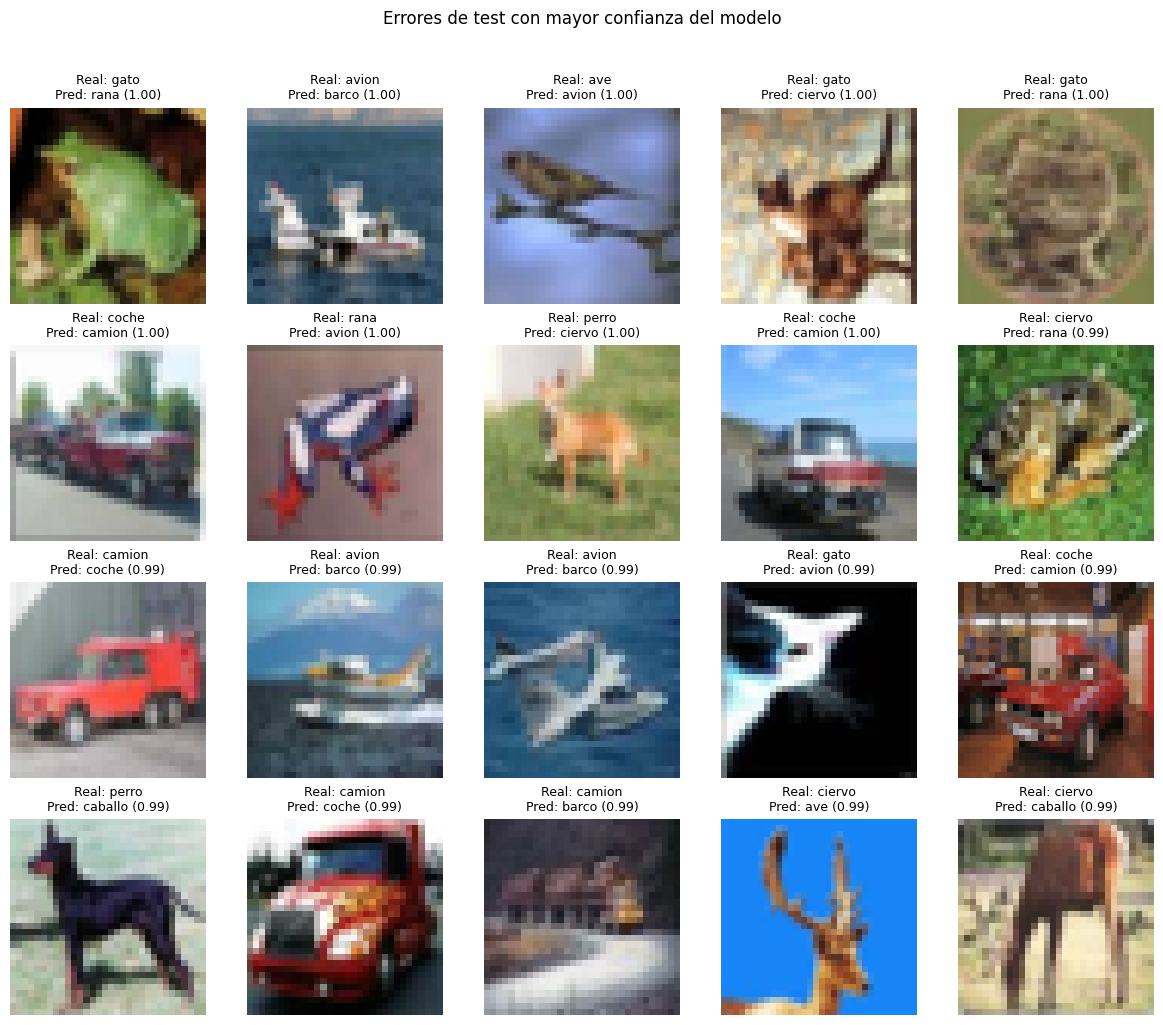

In [39]:
def plot_misclassified_examples(images, y_true, y_pred, probabilities, max_examples=20):
    errors = np.where(y_true != y_pred)[0]
    if len(errors) == 0:
        print("No hay errores en el conjunto seleccionado.")
        return

    confidence = probabilities[errors, y_pred[errors]]
    selected = errors[np.argsort(confidence)[-max_examples:]][::-1]
    cols = 5
    rows = int(np.ceil(len(selected) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 2.5))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, selected):
        ax.imshow(images[idx])
        ax.axis("off")
        real = class_names[y_true[idx]]
        pred = class_names[y_pred[idx]]
        conf = probabilities[idx, y_pred[idx]]
        ax.set_title(f"Real: {real}\nPred: {pred} ({conf:.2f})", fontsize=9)

    for ax in axes[len(selected):]:
        ax.axis("off")

    fig.suptitle("Errores de test con mayor confianza del modelo", y=1.02)
    plt.tight_layout()
    plt.show()

plot_misclassified_examples(x_test, y_test_flat, y_pred, y_pred_proba, max_examples=20)

In [40]:
def top_confusions(y_true, y_pred, top_n=10):
    cm = confusion_matrix(y_true, y_pred)
    rows = []
    for real_id in range(num_classes):
        for pred_id in range(num_classes):
            if real_id != pred_id and cm[real_id, pred_id] > 0:
                rows.append({
                    "clase_real": class_names[real_id],
                    "clase_predicha": class_names[pred_id],
                    "errores": cm[real_id, pred_id],
                })
    return pd.DataFrame(rows).sort_values("errores", ascending=False).head(top_n)

display(top_confusions(y_test_flat, y_pred, top_n=10))

,clase_real,clase_predicha,errores
47,perro,gato,128
31,gato,rana,109
30,gato,perro,96
28,gato,ave,93
29,gato,ciervo,65
22,ave,rana,60
17,ave,avion,58
46,perro,ave,55
16,coche,camion,54
37,ciervo,ave,53


## 11. Informe final y conclusiones

A continuación se resume el comportamiento obtenido por los modelos entrenados. El modelo definitivo se escoge según la accuracy de validación, y posteriormente se confirma su rendimiento con el conjunto de test y con métricas por clase.

In [41]:
def generate_final_report():
    best_row = comparison_df.iloc[0]
    fc_row = comparison_df[comparison_df["modelo"] == "fully_connected"].iloc[0]
    simple_row = comparison_df[comparison_df["modelo"] == "simple_cnn"].iloc[0]
    augmented_row = comparison_df[comparison_df["modelo"] == "final_augmented_cnn"].iloc[0]
    best_classes = class_summary.head(3).index.tolist()
    worst_classes = class_summary.tail(3).index.tolist()
    confusions = top_confusions(y_test_flat, y_pred, top_n=3)

    lines = []
    lines.append("INFORME FINAL DE RESULTADOS")
    lines.append("=" * 80)
    lines.append(
        f"El modelo seleccionado según validación ha sido {best_row['modelo']}, con una accuracy "
        f"de validación de {best_row['valid_accuracy']:.4f}. En el conjunto de test obtuvo una "
        f"accuracy de {best_row['test_accuracy']:.4f} y una loss de {best_row['test_loss']:.4f}."
    )
    lines.append(
        f"El modelo fully connected utilizado como referencia alcanzó una accuracy en test de "
        f"{fc_row['test_accuracy']:.4f}. La mejora absoluta del modelo seleccionado frente a esta "
        f"referencia es de {best_row['test_accuracy'] - fc_row['test_accuracy']:.4f} puntos."
    )
    lines.append(
        f"La CNN simple alcanzó una accuracy en test de {simple_row['test_accuracy']:.4f}, mientras "
        f"que la CNN con data augmentation obtuvo {augmented_row['test_accuracy']:.4f}. Aunque esta "
        f"última mejora claramente a la CNN simple, en esta ejecución no superó a la CNN regularizada."
    )
    lines.append("")
    lines.append("Las clases con mejor F1-score han sido: " + ", ".join(best_classes) + ".")
    lines.append("Las clases con peor F1-score han sido: " + ", ".join(worst_classes) + ".")
    lines.append("")
    lines.append("Principales confusiones observadas:")
    for _, row in confusions.iterrows():
        lines.append(f"- {row['clase_real']} clasificada como {row['clase_predicha']}: {int(row['errores'])} errores.")
    lines.append("")
    lines.append(
        "En conjunto, los resultados muestran que las redes convolucionales son más adecuadas que "
        "el modelo denso para CIFAR-10, porque aprovechan la estructura espacial de las imágenes. "
        "El mejor resultado de esta ejecución se obtiene con una CNN regularizada mediante batch "
        "normalization, dropout y regularización L2."
    )
    return "\n".join(lines)

print(generate_final_report())

INFORME FINAL DE RESULTADOS
El modelo seleccionado según validación ha sido regularized_cnn, con una accuracy de validación de 0.8239. En el conjunto de test obtuvo una accuracy de 0.8172 y una loss de 0.5952.
El modelo fully connected utilizado como referencia alcanzó una accuracy en test de 0.4360. La mejora absoluta del modelo seleccionado frente a esta referencia es de 0.3812 puntos.
La CNN simple alcanzó una accuracy en test de 0.6951, mientras que la CNN con data augmentation obtuvo 0.7974. Aunque esta última mejora claramente a la CNN simple, en esta ejecución no superó a la CNN regularizada.

Las clases con mejor F1-score han sido: coche, barco, camion.
Las clases con peor F1-score han sido: ave, perro, gato.

Principales confusiones observadas:
- perro clasificada como gato: 128 errores.
- gato clasificada como rana: 109 errores.
- gato clasificada como perro: 96 errores.

En conjunto, los resultados muestran que las redes convolucionales son más adecuadas que el modelo denso 

**Conclusión cualitativa.** El modelo fully connected se utiliza como línea base, pero obtiene una accuracy en test de `0.4360`, claramente inferior a la de los modelos convolucionales. Esto confirma que aplanar la imagen en un vector no resulta adecuado para CIFAR-10, ya que se pierde parte de la información espacial que ayuda a reconocer formas, bordes y texturas.

La CNN simple mejora el resultado hasta `0.6951` en test, lo que muestra la utilidad de las capas convolucionales. La CNN con data augmentation consigue `0.7974`, por lo que también mejora de forma clara a la CNN simple. Sin embargo, el mejor resultado de esta ejecución corresponde a la CNN regularizada, con `0.8239` en validación y `0.8172` en test. Esto indica que, para esta configuración concreta, la combinación de mayor profundidad, batch normalization, dropout y regularización L2 ha sido más efectiva que añadir data augmentation al modelo final.

El análisis por clases muestra que las mejores categorías son `coche`, `barco` y `camion`, todas con F1-score superior a `0.90`. Las clases con peor rendimiento son `gato`, `perro` y `ave`. En particular, `gato` tiene un recall de `0.5580`, lo que significa que una parte importante de sus imágenes se clasifican como otras clases. Las principales confusiones son `perro` como `gato`, `gato` como `rana` y `gato` como `perro`, algo coherente con la similitud visual entre animales y con la baja resolución de las imágenes de CIFAR-10.

En conclusión, el modelo seleccionado cumple el objetivo del ejercicio porque supera ampliamente al baseline fully connected, compara varias arquitecturas CNN, incorpora técnicas de regularización y analiza los resultados con métricas, tablas y visualizaciones. La accuracy final de `0.8172` en test puede considerarse un resultado sólido para una CNN entrenada desde cero sobre CIFAR-10.